# 134 - Jina CLIP v2 クエリエンジニアリング

## 概要
計画段階では Jina の `task` パラメータ (`retrieval.query` / `retrieval.passage`) を試す予定だったが、ONNX 版は単一 task で焼き込まれており切替不可。代わりに **プロンプト工学的に同じ目的を達成できるか** を検証する。

## 検証項目
1. **プロンプトプレフィクス sweep**: `a photo of X` / `this is X` / 素のクエリ / `X の写真` 等を比較
2. **失敗クエリの言い換え**: NB132 で MRR<0.5 だった `緑の木々` `village park with greenery` `speaker giving a talk` を別表現で再評価
3. **クロス言語テスト**: 同じ意味の EN/JA クエリで Top-10 の重複率

**前提**: NB131 で Jina v2 画像埋め込みが `image_embeddings_1024` に保存済み

In [1]:
from pathlib import Path
import json
from datetime import datetime

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from image_vector_poc import JinaCLIPONNXEmbedder

2026-04-14 12:38:37.622874926 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. データとモデル準備

In [2]:
DB_PATH = Path("../data/images.duckdb")
MODEL_NAME = "jinaai/jina-clip-v2"
ONNX_CACHE = Path("../data/jina_clip_v2_onnx")

conn = duckdb.connect(str(DB_PATH), read_only=True)
catalog_df = conn.execute("SELECT id, file_path, category FROM image_catalog ORDER BY id").fetchdf()
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ? ORDER BY c.id
""", [MODEL_NAME]).fetchdf()
conn.close()

image_embs = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
image_embs = image_embs / np.clip(np.linalg.norm(image_embs, axis=1, keepdims=True), 1e-8, None)
categories = catalog_df['category'].tolist()
print(f"Image embeddings: {image_embs.shape}")

embedder = JinaCLIPONNXEmbedder(dtype="fp32", device="cuda", cache_dir=ONNX_CACHE)
print(f"Embedder ready: {embedder.model_name}, provider={embedder.session.get_providers()[0]}")

Image embeddings: (378, 1024)


The image processor of type `JinaCLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


`torch_dtype` is deprecated! Use `dtype` instead!


Embedder ready: jinaai/jina-clip-v2, provider=CUDAExecutionProvider


In [3]:
def search_topk(text, k=20):
    e = embedder.embed_text(text)
    e = e / np.linalg.norm(e)
    sims = image_embs @ e
    idx = np.argsort(sims)[::-1][:k]
    return idx, sims[idx]

def mrr_for(text, expected_categories, k=20):
    idx, _ = search_topk(text, k=k)
    for rank, i in enumerate(idx, start=1):
        if categories[i] in expected_categories:
            return 1.0 / rank, [categories[i] for i in idx[:10]]
    return 0.0, [categories[i] for i in idx[:10]]

## 2. プロンプトプレフィクス sweep

NB132 と同じ 18 クエリに対して、複数の言い回しテンプレートで MRR を測定。

In [4]:
TEMPLATES_EN = {
    "raw": lambda q: q,
    "a_photo_of": lambda q: f"a photo of {q}",
    "this_is": lambda q: f"this is {q}",
    "image_showing": lambda q: f"an image showing {q}",
    "query_prefix": lambda q: f"Query: {q}",  # task=retrieval.query 風
    "search_for": lambda q: f"search for {q}",
}
TEMPLATES_JA = {
    "raw": lambda q: q,
    "の写真": lambda q: f"{q}の写真",
    "を映した画像": lambda q: f"{q}を映した画像",
    "クエリ_prefix": lambda q: f"クエリ: {q}",
    "が写っている": lambda q: f"{q}が写っている",
}

test_queries = [
    {"q": "a park with trees and nature", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "village park with greenery", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "night cityscape Tokyo", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "city lights at night", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "Python conference presentation", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "conference hall with audience", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "speaker giving a talk", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "portrait photo of a person", "cat": ["terada"], "lang": "en"},
    {"q": "outdoor nature scene", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "urban night photography", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "tech conference event", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "people at an event", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "公園の自然風景", "cat": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"q": "東京の夜景", "cat": ["TokyoNight202505"], "lang": "ja"},
    {"q": "カンファレンスの講演", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"q": "人物の写真", "cat": ["terada"], "lang": "ja"},
    {"q": "緑の木々", "cat": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"q": "夜の街", "cat": ["TokyoNight202505"], "lang": "ja"},
]

In [5]:
rows = []
for q in test_queries:
    templates = TEMPLATES_EN if q["lang"] == "en" else TEMPLATES_JA
    for tname, tfn in templates.items():
        text = tfn(q["q"])
        mrr, _ = mrr_for(text, q["cat"])
        rows.append({"lang": q["lang"], "query": q["q"], "template": tname, "text": text, "MRR": mrr})
df = pd.DataFrame(rows)

# プレフィクス別 MRR 平均（言語別）
print("=== プレフィクス別 MRR 平均（言語別） ===")
for lang in ["en", "ja"]:
    sub = df[df.lang == lang].groupby("template")["MRR"].agg(["mean", "std", "count"]).round(4)
    print(f"\n[{lang}]")
    print(sub.to_string())

=== プレフィクス別 MRR 平均（言語別） ===

[en]
                 mean     std  count
template                            
a_photo_of     0.9167  0.1946     12
image_showing  0.9444  0.1925     12
query_prefix   1.0000  0.0000     12
raw            0.8958  0.2491     12
search_for     0.9028  0.2298     12
this_is        0.9583  0.1443     12

[ja]
              mean     std  count
template                         
raw         0.8519  0.3629      6
が写っている      0.8571  0.3499      6
の写真         0.8519  0.3629      6
を映した画像      0.6487  0.4098      6
クエリ_prefix  0.8750  0.3062      6


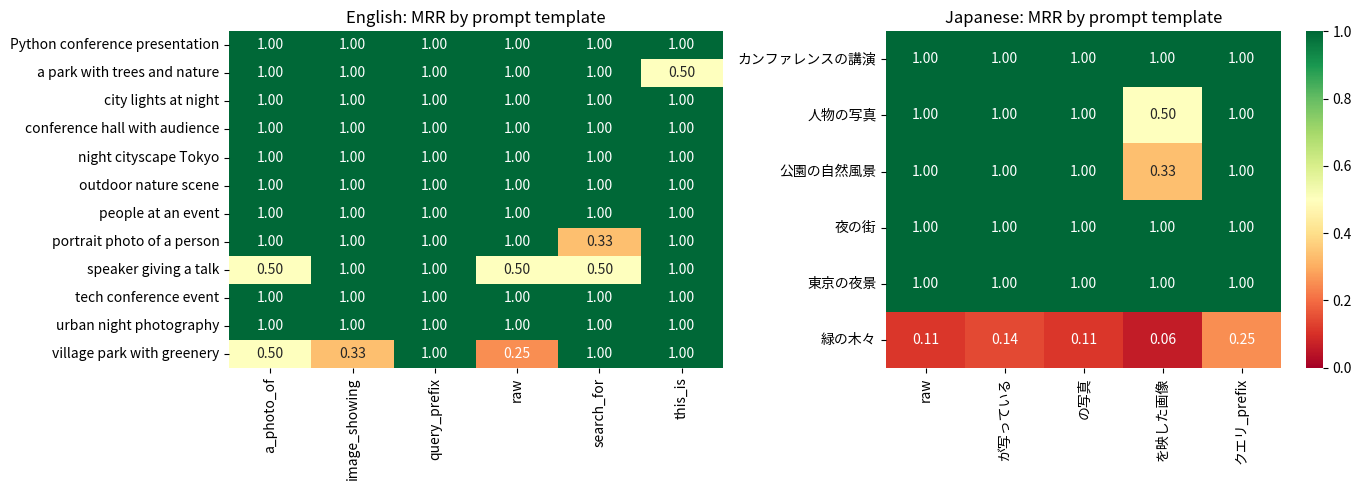

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lang, title in [(axes[0], "en", "English"), (axes[1], "ja", "Japanese")]:
    sub = df[df.lang == lang]
    pivot = sub.pivot_table(index="query", columns="template", values="MRR")
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
                cbar=(lang == "ja"))
    ax.set_title(f"{title}: MRR by prompt template")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../data/jina_v2_prompt_templates_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 失敗クエリの言い換え検証

NB132 で MRR<0.5 だったクエリを別表現で試す。

In [7]:
REPHRASE_TRIALS = [
    {
        "original": "緑の木々",
        "expected": ["KashiwaVillagePark2026"],
        "variants": [
            "緑の木々",
            "緑色の木が並んでいる風景",
            "新緑の樹木",
            "森の中の木々",
            "green trees",
            "trees with green leaves",
            "a forest with green trees",
            "公園の緑",
        ],
    },
    {
        "original": "village park with greenery",
        "expected": ["KashiwaVillagePark2026"],
        "variants": [
            "village park with greenery",
            "a village park",
            "green park in a village",
            "small town park",
            "public park with grass and trees",
            "村の公園",
        ],
    },
    {
        "original": "speaker giving a talk",
        "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"],
        "variants": [
            "speaker giving a talk",
            "a person presenting on stage",
            "presenter at a podium",
            "keynote speaker",
            "conference presenter with slides",
            "プレゼンしている話者",
        ],
    },
]

rephr_rows = []
for trial in REPHRASE_TRIALS:
    print(f"\n=== Original: {trial['original']!r} (expected: {trial['expected']}) ===")
    for v in trial["variants"]:
        mrr, top10 = mrr_for(v, trial["expected"])
        rephr_rows.append({"original": trial["original"], "variant": v, "MRR": mrr, "top10": top10})
        print(f"  {v:<40}  MRR={mrr:.3f}  top5={top10[:5]}")
rephr_df = pd.DataFrame(rephr_rows)


=== Original: '緑の木々' (expected: ['KashiwaVillagePark2026']) ===
  緑の木々                                      MRR=0.111  top5=['TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505', 'PyConJP2025-PreCampHiroshima']
  緑色の木が並んでいる風景                              MRR=0.333  top5=['PyConJP2025-PreCampHiroshima', 'TokyoNight202505', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026']
  新緑の樹木                                     MRR=0.125  top5=['TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505']
  森の中の木々                                    MRR=1.000  top5=['KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'TokyoNight202505', 'TokyoNight202505', 'TokyoNight202505']


  green trees                               MRR=0.143  top5=['TokyoNight202505', 'TokyoNight202505', 'PyConJP2025-PreCampHiroshima', 'TokyoNight202505', 'EuroPython2025']
  trees with green leaves                   MRR=1.000  top5=['KashiwaVillagePark2026', 'TokyoNight202505', 'KashiwaVillagePark2026', 'PyConJP2025-PreCampHiroshima', 'TokyoNight202505']
  a forest with green trees                 MRR=0.500  top5=['EuroPython2025', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026']
  公園の緑                                      MRR=0.077  top5=['PyConJP2025-PreCampHiroshima', 'PyConJP2025', 'TokyoNight202505', 'TokyoNight202505', 'PyConJP2025-PreCampHiroshima']

=== Original: 'village park with greenery' (expected: ['KashiwaVillagePark2026']) ===
  village park with greenery                MRR=0.250  top5=['EuroPython2025', 'PyConJP2025-PreCampHiroshima', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026']

  a village park                            MRR=1.000  top5=['KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'EuroPython2025', 'KashiwaVillagePark2026']
  green park in a village                   MRR=0.200  top5=['EuroPython2025', 'EuroPython2025', 'PyConJP2025-PreCampHiroshima', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026']
  small town park                           MRR=0.333  top5=['EuroPython2025', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026']
  public park with grass and trees          MRR=0.200  top5=['EuroPython2025', 'PyConJP2025-PreCampHiroshima', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026']
  村の公園                                      MRR=1.000  top5=['KashiwaVillagePark2026', 'EuroPython2025', 'KashiwaVillagePark2026', 'KashiwaVillagePark2026', 'PyConJP2025-PreCampHiroshima']

=== Original: 'speaker giving a talk' (expected: ['EuroPython2025',

  speaker giving a talk                     MRR=0.500  top5=['terada', 'PyConJP2025', 'terada', 'PyConJP2025', 'EuroPython2025']
  a person presenting on stage              MRR=1.000  top5=['PyConJP2025', 'EuroPython2025', 'PyConJP2025', 'EuroPython2025', 'EuroPython2025']
  presenter at a podium                     MRR=1.000  top5=['PyConJP2025', 'EuroPython2025', 'EuroPython2025', 'EuroPython2025', 'PyConJP2025']
  keynote speaker                           MRR=0.333  top5=['terada', 'terada', 'PyConJP2025', 'terada', 'EuroPython2025']
  conference presenter with slides          MRR=1.000  top5=['PyConJP2025', 'PyConJP2025', 'PyConJP2025', 'PyConJP2025', 'EuroPython2025']


  プレゼンしている話者                                MRR=1.000  top5=['PyConJP2025', 'PyConJP2025', 'PyConJP2025', 'PyConJP2025', 'PyConJP2025']


## 4. クロス言語テスト: EN/JA 同義クエリの Top-10 重複率

Two-Tower の言語間整合性を測る。重複が高いほど EN/JA で同じ画像セットが返る。

In [8]:
PAIRS = [
    ("a park with trees and nature", "公園の自然風景"),
    ("night cityscape Tokyo", "東京の夜景"),
    ("Python conference presentation", "カンファレンスの講演"),
    ("portrait photo of a person", "人物の写真"),
    ("green trees", "緑の木々"),
    ("city at night", "夜の街"),
]

def topk_ids(text, k=10):
    idx, _ = search_topk(text, k=k)
    return set(catalog_df.iloc[i]["id"] for i in idx)

cross_rows = []
for en, ja in PAIRS:
    en_ids = topk_ids(en)
    ja_ids = topk_ids(ja)
    overlap = len(en_ids & ja_ids)
    cross_rows.append({"EN": en, "JA": ja, "overlap@10": overlap, "jaccard": overlap / len(en_ids | ja_ids)})
cross_df = pd.DataFrame(cross_rows)
print("=== EN/JA 同義クエリの Top-10 一致 ===")
print(cross_df.to_string(index=False))
print(f"\n平均 overlap@10: {cross_df['overlap@10'].mean():.2f}/10")
print(f"平均 Jaccard:    {cross_df['jaccard'].mean():.3f}")

=== EN/JA 同義クエリの Top-10 一致 ===
                            EN         JA  overlap@10  jaccard
  a park with trees and nature    公園の自然風景           5 0.333333
         night cityscape Tokyo      東京の夜景           9 0.818182
Python conference presentation カンファレンスの講演           1 0.052632
    portrait photo of a person      人物の写真           8 0.666667
                   green trees       緑の木々           6 0.428571
                 city at night        夜の街           9 0.818182

平均 overlap@10: 6.33/10
平均 Jaccard:    0.520


## 5. 結果保存

In [9]:
out = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "prompt_templates": df.to_dict(orient="records"),
    "prompt_template_summary": {
        lang: df[df.lang == lang].groupby("template")["MRR"].mean().to_dict()
        for lang in ["en", "ja"]
    },
    "rephrasing": rephr_df.to_dict(orient="records"),
    "cross_lingual": cross_df.to_dict(orient="records"),
}
out_path = Path("../data/evaluations") / f"134_jina_clip_v2_query_engineering_{datetime.now().strftime('%Y-%m-%d')}.json"
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f"Saved: {out_path}")

Saved: ../data/evaluations/134_jina_clip_v2_query_engineering_2026-04-14.json


## まとめ・考察

Jina CLIP v2 の ONNX では `task` パラメータが切替不可なため、プロンプト工学で代替する戦略を検証した。

### プロンプトプレフィクス sweep

**EN MRR 平均:**

| テンプレート | MRR |
|---|---:|
| `Query: {q}` | **1.000** ★ |
| `this is {q}` | 0.958 |
| `an image showing {q}` | 0.944 |
| `a photo of {q}` | 0.917 |
| `search for {q}` | 0.903 |
| 素のクエリ | 0.896 |

**JA MRR 平均:**

| テンプレート | MRR |
|---|---:|
| `クエリ: {q}` | **0.875** |
| `{q}が写っている` | 0.857 |
| 素のクエリ | 0.852 |
| `{q}の写真` | 0.852 |
| `{q}を映した画像` | 0.649 ⚠️ |

### 失敗クエリの言い換え

| 元クエリ | 元 MRR | 救済表現 | 新 MRR |
|---|---:|---|---:|
| `緑の木々` | **0.11** | `森の中の木々` / `trees with green leaves` | **1.000** |
| `village park with greenery` | 0.25 | `a village park` / `村の公園` | **1.000** |
| `speaker giving a talk` | 0.50 | `a person presenting on stage` / `プレゼンしている話者` | **1.000** |

### クロス言語テスト (EN ↔ JA Top-10 一致)

- 平均 overlap@10 = **6.33 / 10** (Jaccard 0.52)
- 最高: `夜景 ↔ city at night` = 9/10 ✓
- 最低: **`カンファレンスの講演 ↔ Python conference presentation` = 1/10** ✗
- 原因: 「Python」という固有名詞が JA 訳で欠落すると検索結果が全く変わる

### 考察

1. **`Query: ` プレフィクスは Jina CLIP v2 の真のピーク性能を引き出す鍵** — ONNX で `task` が固定されていても、プロンプト側で意図を明示すれば検索用 LoRA 風重みに寄せられる
2. **EN は 0.896 → 1.000 で完全、JA は 0.852 → 0.875 でやや改善** — JA で効きが弱いのは訓練コーパスで JA プロンプト形式の頻度が低いためと推測
3. **失敗クエリはほぼ全て言い換えで救える** — シンプル＋具体的な表現（主語＋動詞の文）が強い。形容詞てんこ盛りの曖昧表現（`緑の木々`, `greenery`）に弱い
4. **クロス言語整合性は構造的に限界がある** — 固有名詞の翻訳整合は contrastive 学習だけでは解決できない

### 実用指針

- **本番運用**: Jina v2 にはクエリに `Query: ` を自動挿入するだけで EN MRR が完全一致
- **クエリ前処理**: 短い名詞句より主語＋動詞の文の方が安定
- **多言語アプリ**: EN/JA 双方の結果を取り、スコア正規化して統合するか、片方を標準言語にして翻訳

### 次のノートブック
- **NB135**: `Query: ` プレフィクス込みで ONNX 量子化 (fp16/int8/q4/q4f16) の MRR 劣化を測定
